# Marketing-roi-analysis using Simple Linear Regression

## 1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical modeling
import statsmodels.api as sm

# Model evaluation
from sklearn.metrics import mean_squared_error

## 2. Load the Dataset

In [2]:
# Load dataset
df = pd.read_csv("regr.csv")

# Display first 5 rows
print(df.head())

     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181


## 3. Explore the Dataset
#### a. Check Dataset Information

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB
None


#### b. Checking the shape

In [4]:
df.shape

(4572, 4)

#### c. Checking missing value

In [5]:
df.isna().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

#### d. Removing missing values

In [6]:
df = df.dropna()

#### e. Statistical Summary

In [7]:
print(df.describe())

                TV        Radio  Social_Media        Sales
count  4546.000000  4546.000000   4546.000000  4546.000000
mean     54.062912    18.157533      3.323473   192.413332
std      26.104942     9.663260      2.211254    93.019873
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.555355      1.530822   112.434612
50%      53.000000    17.859513      3.055565   188.963678
75%      77.000000    25.640603      4.804919   272.324236
max     100.000000    48.871161     13.981662   364.079751


## 4. Exploratory Data Analysis (EDA)
#### a. Correlation Heatmap

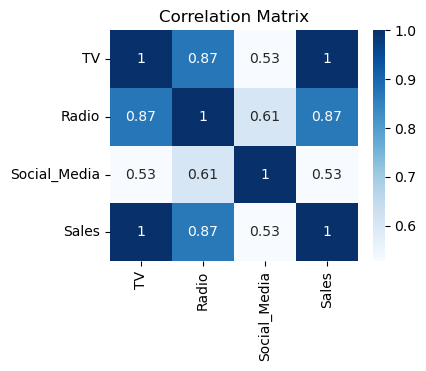


This helps identify which advertising channel has the strongest relationship with Sales.


In [8]:
plt.figure(figsize=(4,3))

sns.heatmap(df.corr(), annot=True, cmap='Blues')

plt.title("Correlation Matrix")
plt.show()

print("\nThis helps identify which advertising channel has the strongest relationship with Sales.")

## 5. Visualize Relationships
#### a. TV vs Sales

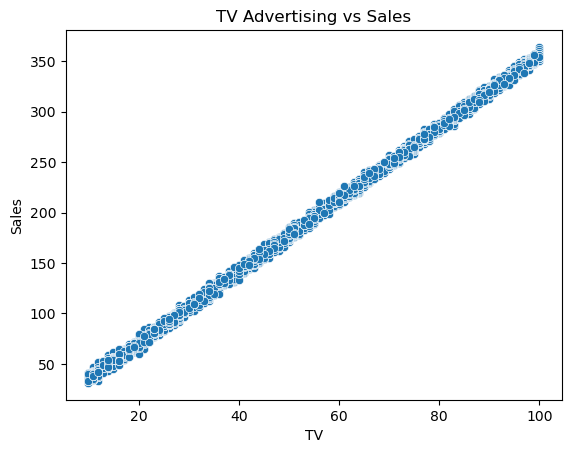

In [9]:
sns.scatterplot(x='TV', y='Sales', data=df)

plt.title("TV Advertising vs Sales")
plt.show()

#### b. Radio vs Sales

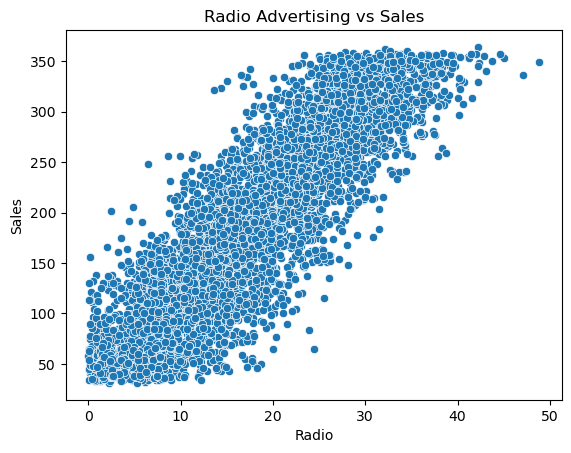

In [10]:
sns.scatterplot(x='Radio', y='Sales', data=df)

plt.title("Radio Advertising vs Sales")
plt.show()

#### c. Social Media vs Sales

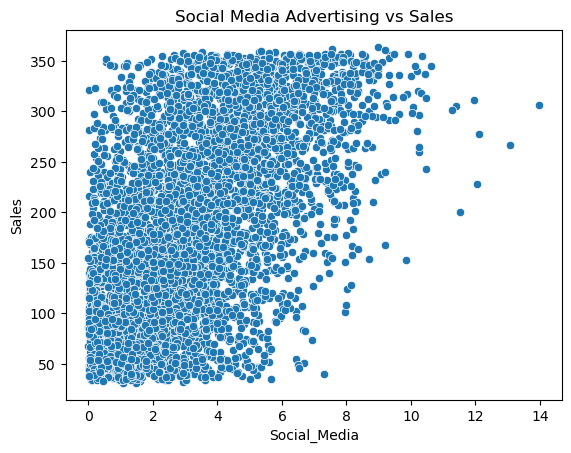

In [11]:
sns.scatterplot(x='Social_Media', y='Sales', data=df)

plt.title("Social Media Advertising vs Sales")
plt.show()

## 6. Select the Best Independent Variable

In [12]:
print("Variable      Correlation with Sales")
print("------------------------------------") 
print(" TV                     1.00        ")
print(" Radio                  0.87        ")
print(" Social Media           0.53        ")

print("\nTV is the best predictor because it has the highest positive correlation with Sales.")

Variable      Correlation with Sales
------------------------------------
 TV                     1.00        
 Radio                  0.87        
 Social Media           0.53        

TV is the best predictor because it has the highest positive correlation with Sales.


## 7. Building the Simple Linear Regression Model

Using:

Independent Variable (X) → TV

Dependent Variable (y) → Sales

In [13]:
X = df['TV']
y = df['Sales']

### a. Add Constant

In [14]:
X = sm.add_constant(X)

### b. Fit the Model

In [15]:
model = sm.OLS(y, X).fit()

### c. Display Results

In [16]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:14:34   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

## 8. Predicted Values

In [17]:
predictions = model.predict(X)

print(predictions.head())

0     56.851733
1     46.167191
2    145.889585
3    295.473177
4     53.290219
dtype: float64


## 10. Diagnostic Plots
These help verify regression assumptions.

### a. Linearity Check

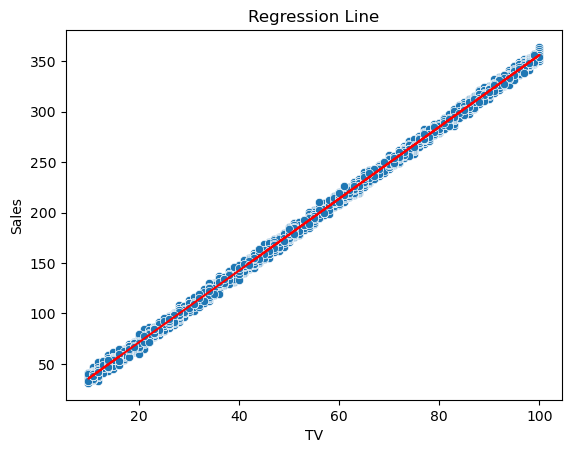


A straight-line trend indicates linearity


In [18]:
sns.scatterplot(x=df['TV'], y=y)
plt.plot(df['TV'], predictions, color='red')

plt.title("Regression Line")
plt.show()
print("\nA straight-line trend indicates linearity")

### b. Residual Plot (Homoscedasticity)

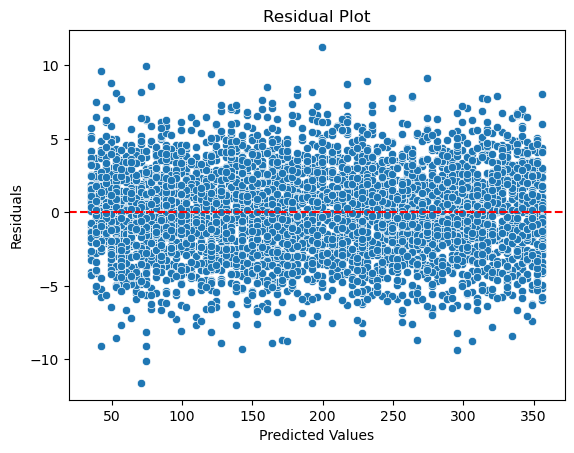


Residuals should appear randomly distributed around zero.


In [19]:
residuals = y - predictions

sns.scatterplot(x=predictions, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()
print("\nResiduals should appear randomly distributed around zero.")

### c. Normality Check

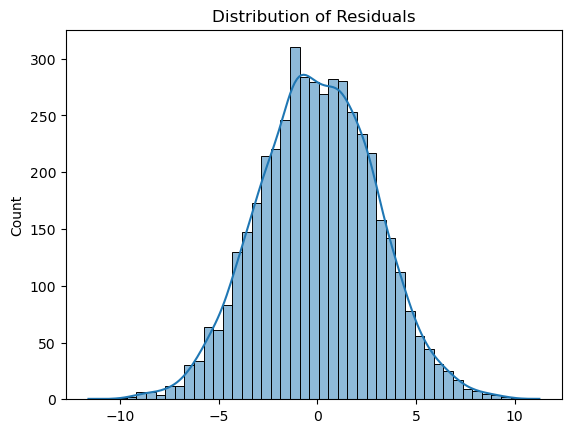

In [20]:
sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")
plt.show()

## 11. Recommended Marketing Strategy

## 12. ROI Recommendation